In [1]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import norm

from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (8,5)

In [2]:
# True values

MU_TRUE = 1.0

SIGMA_TRUE = 0.05

N_EVENTS = 1000

In [3]:
np.random.seed(42)

In [4]:
toy = np.random.normal(
    loc=MU_TRUE,
    scale=SIGMA_TRUE,
    size=N_EVENTS
)

In [5]:
toy[:10]

array([1.02483571, 0.99308678, 1.03238443, 1.07615149, 0.98829233,
       0.98829315, 1.07896064, 1.03837174, 0.97652628, 1.027128  ])

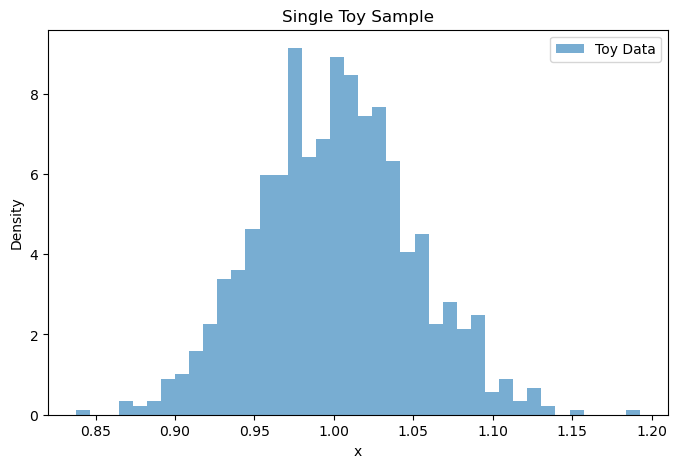

In [6]:
counts, bins, _ = plt.hist(
    toy,
    bins=40,
    density=True,
    alpha=0.6,
    label="Toy Data"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Single Toy Sample")
plt.legend()

plt.show()

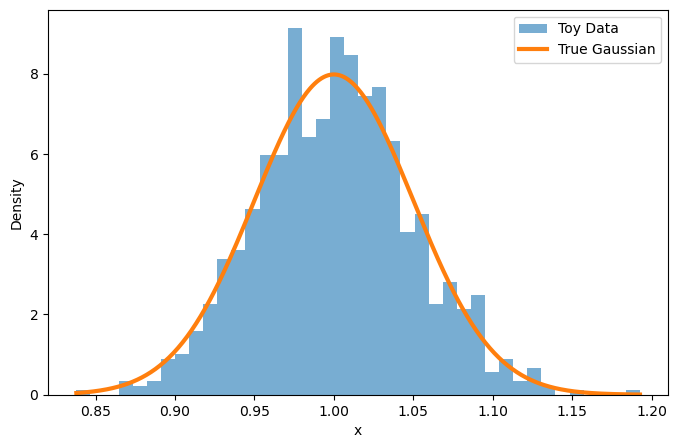

In [7]:
x = np.linspace(
    toy.min(),
    toy.max(),
    500
)

pdf = norm.pdf(
    x,
    MU_TRUE,
    SIGMA_TRUE
)

plt.hist(
    toy,
    bins=40,
    density=True,
    alpha=0.6,
    label="Toy Data"
)

plt.plot(
    x,
    pdf,
    lw=3,
    label="True Gaussian"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

plt.show()

In [8]:
def gaussian(x, A, mu, sigma):

    return (
        A
        * np.exp(
            -(x - mu)**2 /
            (2*sigma**2)
        )
    )

In [9]:
counts, bins = np.histogram(
    toy,
    bins=40
)

centers = 0.5*(bins[1:] + bins[:-1])

errors = np.sqrt(counts)

errors[errors == 0] = 1

In [10]:
p0 = [
    counts.max(),
    np.mean(toy),
    np.std(toy, ddof=1)
]

popt, pcov = curve_fit(
    gaussian,
    centers,
    counts,
    p0=p0,
    sigma=errors,
    absolute_sigma=True
)

A_fit, mu_fit, sigma_fit = popt

In [11]:
perr = np.sqrt(
    np.diag(pcov)
)

A_err, mu_err, sigma_err = perr

print("mu_fit     =", mu_fit)
print("mu_error   =", mu_err)

print()

print("sigma_fit  =", sigma_fit)
print("sigma_err  =", sigma_err)

mu_fit     = 0.999607784021545
mu_error   = 0.001554791714680806

sigma_fit  = 0.04760626860695768
sigma_err  = 0.0011565779064901804


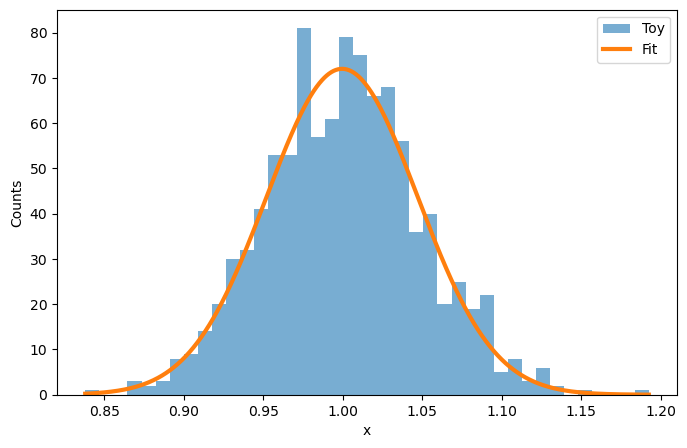

In [12]:
xfit = np.linspace(
    bins[0],
    bins[-1],
    1000
)

plt.hist(
    toy,
    bins=40,
    alpha=0.6,
    label="Toy"
)

plt.plot(
    xfit,
    gaussian(xfit,*popt),
    lw=3,
    label="Fit"
)

plt.xlabel("x")
plt.ylabel("Counts")

plt.legend()

plt.show()

In [13]:
pull_mu = (
    mu_fit - MU_TRUE
)/mu_err

pull_sigma = (
    sigma_fit - SIGMA_TRUE
)/sigma_err

print("Pull(mu)    =", pull_mu)
print("Pull(sigma) =", pull_sigma)

Pull(mu)    = -0.2522627145176664
Pull(sigma) = -2.0696672308971236


In [14]:
mu_fit = np.mean(toy)

sigma_fit = np.std(toy, ddof=1)

mu_err = sigma_fit / np.sqrt(len(toy))

sigma_err = sigma_fit / np.sqrt(2*(len(toy)-1))

print(f"mu_fit     = {mu_fit:.8f}")
print(f"mu_err     = {mu_err:.8f}")

print()

print(f"sigma_fit  = {sigma_fit:.8f}")
print(f"sigma_err  = {sigma_err:.8f}")

mu_fit     = 1.00096660
mu_err     = 0.00154828

sigma_fit  = 0.04896080
sigma_err  = 0.00109534


In [15]:
pull_mu = (mu_fit - MU_TRUE)/mu_err

pull_sigma = (sigma_fit - SIGMA_TRUE)/sigma_err

print(f"Pull(mu)    = {pull_mu:.4f}")
print(f"Pull(sigma) = {pull_sigma:.4f}")

Pull(mu)    = 0.6243
Pull(sigma) = -0.9487


In [16]:
N_TOYS = 500

In [17]:
pull_mu_list = []

pull_sigma_list = []

mu_fit_list = []

sigma_fit_list = []

mu_err_list = []

sigma_err_list = []

In [18]:
for i in range(N_TOYS):

    toy = np.random.normal(
        loc=MU_TRUE,
        scale=SIGMA_TRUE,
        size=N_EVENTS
    )

    counts, bins = np.histogram(
        toy,
        bins=40
    )

    centers = 0.5*(bins[1:] + bins[:-1])

    errors = np.sqrt(counts)

    errors[errors == 0] = 1

    p0 = [
        counts.max(),
        np.mean(toy),
        np.std(toy, ddof=1)
    ]

    try:

        popt, pcov = curve_fit(
            gaussian,
            centers,
            counts,
            p0=p0,
            sigma=errors,
            absolute_sigma=True
        )

        A_fit, mu_fit, sigma_fit = popt

        perr = np.sqrt(
            np.diag(pcov)
        )

        A_err, mu_err, sigma_err = perr

        pull_mu = (
            mu_fit - MU_TRUE
        ) / mu_err

        pull_sigma = (
            sigma_fit - SIGMA_TRUE
        ) / sigma_err

        pull_mu_list.append(
            pull_mu
        )

        pull_sigma_list.append(
            pull_sigma
        )

        mu_fit_list.append(
            mu_fit
        )

        sigma_fit_list.append(
            sigma_fit
        )

        mu_err_list.append(
            mu_err
        )

        sigma_err_list.append(
            sigma_err
        )

    except RuntimeError:

        continue

In [19]:
pull_mu = np.array(
    pull_mu_list
)

pull_sigma = np.array(
    pull_sigma_list
)

mu_fit_array = np.array(
    mu_fit_list
)

sigma_fit_array = np.array(
    sigma_fit_list
)

In [20]:
print(
    "Successful fits =",
    len(pull_mu)
)

Successful fits = 500


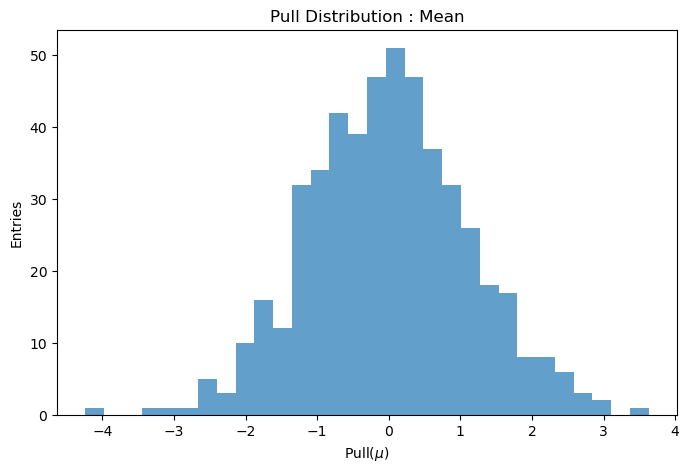

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    pull_mu,
    bins=30,
    alpha=0.7
)

plt.xlabel(
    r"Pull($\mu$)"
)

plt.ylabel(
    "Entries"
)

plt.title(
    "Pull Distribution : Mean"
)

plt.show()

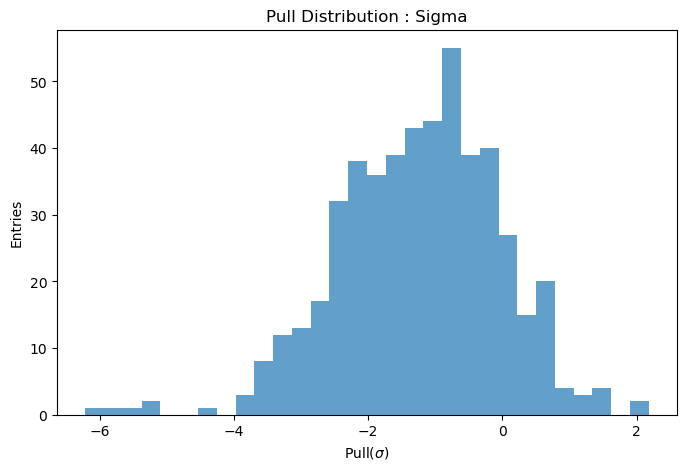

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    pull_sigma,
    bins=30,
    alpha=0.7
)

plt.xlabel(
    r"Pull($\sigma$)"
)

plt.ylabel(
    "Entries"
)

plt.title(
    "Pull Distribution : Sigma"
)

plt.show()

In [23]:
mean_pull_mu = np.mean(
    pull_mu
)

std_pull_mu = np.std(
    pull_mu,
    ddof=1
)

mean_pull_sigma = np.mean(
    pull_sigma
)

std_pull_sigma = np.std(
    pull_sigma,
    ddof=1
)

print(
    "Mean Pull(mu)  =",
    mean_pull_mu
)

print(
    "Width Pull(mu) =",
    std_pull_mu
)

print()

print(
    "Mean Pull(sigma)  =",
    mean_pull_sigma
)

print(
    "Width Pull(sigma) =",
    std_pull_sigma
)

Mean Pull(mu)  = -0.008914422611159602
Width Pull(mu) = 1.1278680293968368

Mean Pull(sigma)  = -1.2334170792739216
Width Pull(sigma) = 1.1988707884517922


In [24]:
print(
    "Average fitted mean =",
    np.mean(mu_fit_array)
)

print(
    "True mean =",
    MU_TRUE
)

Average fitted mean = 0.999984846773089
True mean = 1.0


In [25]:
print(
    "Average fitted sigma =",
    np.mean(sigma_fit_array)
)

print(
    "True sigma =",
    SIGMA_TRUE
)

Average fitted sigma = 0.0485939944294314
True sigma = 0.05


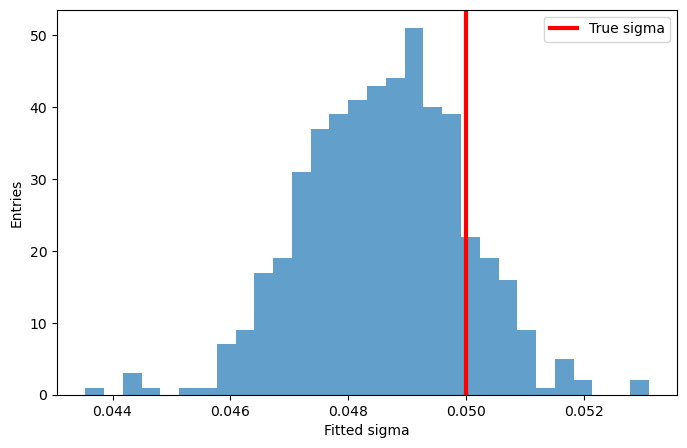

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    sigma_fit_array,
    bins=30,
    alpha=0.7
)

plt.axvline(
    SIGMA_TRUE,
    color='red',
    linewidth=3,
    label='True sigma'
)

plt.xlabel("Fitted sigma")
plt.ylabel("Entries")

plt.legend()

plt.show()

In [27]:
counts_mu, bins_mu = np.histogram(
    pull_mu,
    bins=30
)

centers_mu = 0.5*(bins_mu[1:] + bins_mu[:-1])

p0 = [
    counts_mu.max(),
    np.mean(pull_mu),
    np.std(pull_mu, ddof=1)
]

popt_mu, pcov_mu = curve_fit(
    gaussian,
    centers_mu,
    counts_mu,
    p0=p0
)

A_mu, mean_mu_fit, sigma_mu_fit = popt_mu

print("Gaussian fit to Pull(mu)")
print("Mean  =", mean_mu_fit)
print("Sigma =", sigma_mu_fit)

Gaussian fit to Pull(mu)
Mean  = -0.03713190974101632
Sigma = 1.0902105631891768


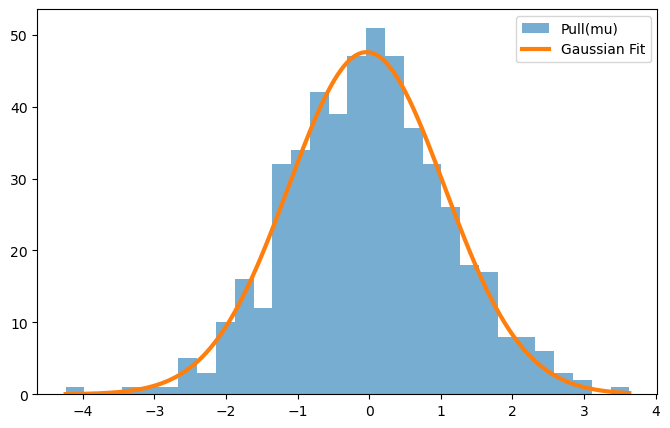

In [28]:
xfit = np.linspace(
    bins_mu[0],
    bins_mu[-1],
    1000
)

plt.hist(
    pull_mu,
    bins=30,
    alpha=0.6,
    label="Pull(mu)"
)

plt.plot(
    xfit,
    gaussian(xfit,*popt_mu),
    lw=3,
    label="Gaussian Fit"
)

plt.legend()

plt.show()

In [29]:
counts_sig, bins_sig = np.histogram(
    pull_sigma,
    bins=30
)

centers_sig = 0.5*(bins_sig[1:] + bins_sig[:-1])

p0 = [
    counts_sig.max(),
    np.mean(pull_sigma),
    np.std(pull_sigma, ddof=1)
]

popt_sig, pcov_sig = curve_fit(
    gaussian,
    centers_sig,
    counts_sig,
    p0=p0
)

A_sig, mean_sig_fit, sigma_sig_fit = popt_sig

print("Gaussian fit to Pull(sigma)")
print("Mean  =", mean_sig_fit)
print("Sigma =", sigma_sig_fit)

Gaussian fit to Pull(sigma)
Mean  = -1.1543211997472198
Sigma = 1.1783035541928573


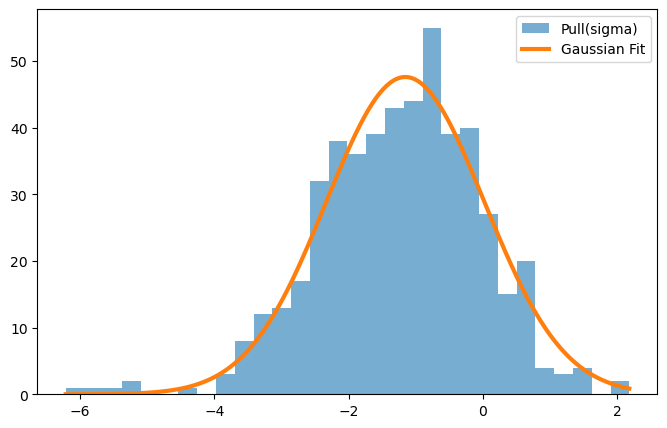

In [30]:
xfit = np.linspace(
    bins_sig[0],
    bins_sig[-1],
    1000
)

plt.hist(
    pull_sigma,
    bins=30,
    alpha=0.6,
    label="Pull(sigma)"
)

plt.plot(
    xfit,
    gaussian(xfit,*popt_sig),
    lw=3,
    label="Gaussian Fit"
)

plt.legend()

plt.show()